# Análise de Fauna

Foca na **fauna**: quanto cada agente joga de cada tipo, o uso da **capacidade habitacional**, a
economia de **O2** (produção sustenta a fauna; excesso de animais é sacrificado), e a contribuição
da fauna ao **score**. Agrupa por **agente** (justo com `randomize_seats`).

Usa `turn_states.csv` (progressão por rodada) e o `results.csv` do mesmo torneio (volume por tipo).

In [11]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()


def find_latest_turn_states(root: Path) -> Path:
    base = root / 'artifacts' / 'tournaments'
    for d in sorted(base.glob('*/'), key=lambda p: p.stat().st_mtime, reverse=True):
        ts = d / 'turn_states.csv'
        if ts.exists() and 'fauna_count' in pd.read_csv(ts, nrows=0).columns:
            return ts
    raise FileNotFoundError('Nenhum turn_states.csv com coluna fauna_count. Rode um torneio novo.')


ts_path = find_latest_turn_states(ROOT)
print('Usando:', ts_path.parent.name)
df = pd.read_csv(ts_path)


def read_meta(csv_path):
    m = csv_path.parent / 'metadata.json'
    return json.loads(m.read_text(encoding='utf-8')).get('tournament_config', {}) if m.exists() else {}

meta = read_meta(ts_path)
if 'agent' not in df.columns:
    df['agent'] = df['player'].map({1: meta.get('agent_p1', 'P1'), 2: meta.get('agent_p2', 'P2')})

# fim-de-rodada por (jogo, jogador, rodada) -> média entre jogos por (rodada, agente)
eor = df.loc[df.groupby(['seed', 'player', 'round'])['turn'].idxmax()]
agg = eor.groupby(['round', 'agent']).mean(numeric_only=True).reset_index()
agents = sorted(agg['agent'].unique())
print('Agentes:', agents, '| jogos:', df['seed'].nunique())


def series(metric, agent):
    s = agg[agg['agent'] == agent].set_index('round')[metric].sort_index()
    return s.index, s.values

Usando: 20260719T092932Z_v0.1.0
Agentes: ['greedy', 'longterm'] | jogos: 250


## Fauna no board e capacidade habitacional, por agente

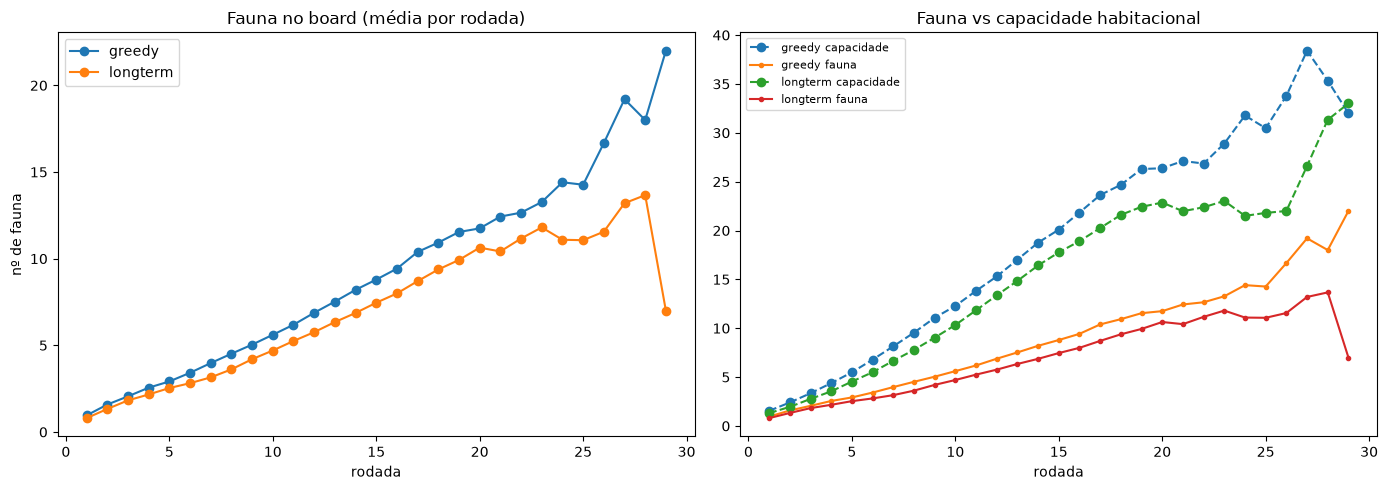

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for a in agents:
    x, y = series('fauna_count', a); axes[0].plot(x, y, marker='o', label=a)
axes[0].set_title('Fauna no board (média por rodada)'); axes[0].set_xlabel('rodada'); axes[0].set_ylabel('nº de fauna'); axes[0].legend()
for a in agents:
    x, y = series('habitat_capacity', a); axes[1].plot(x, y, marker='o', linestyle='--', label=f'{a} capacidade')
    x, y = series('fauna_count', a); axes[1].plot(x, y, marker='.', label=f'{a} fauna')
axes[1].set_title('Fauna vs capacidade habitacional'); axes[1].set_xlabel('rodada'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Economia de O2 (sustento da fauna)

A produção de O2 é a capacidade de sustento: cada fauna consome 1 O2/rodada e o excesso é sacrificado.
`produced_o2` é o O2 **excedente acumulado** (net, depois do consumo) — cresce quando sobra produção.

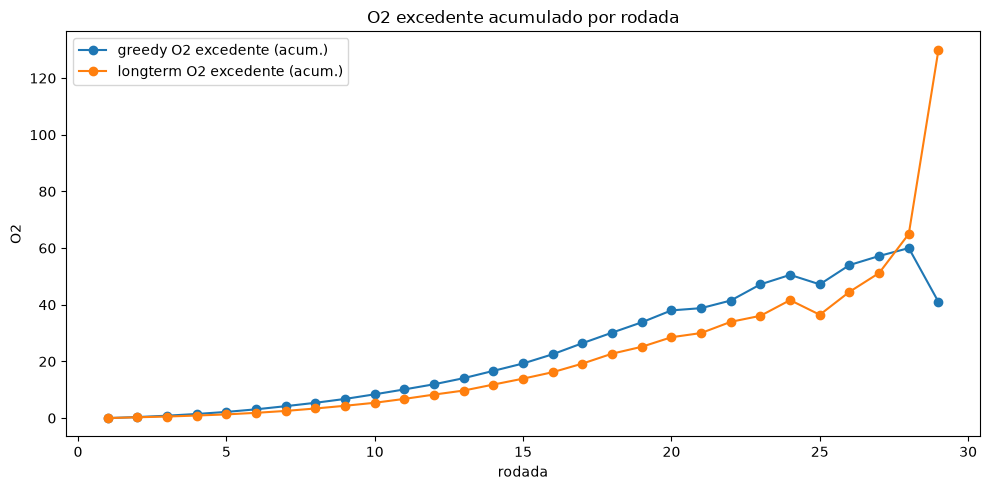

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
for a in agents:
    x, y = series('produced_o2', a); ax.plot(x, y, marker='o', label=f'{a} O2 excedente (acum.)')
ax.set_title('O2 excedente acumulado por rodada'); ax.set_xlabel('rodada'); ax.set_ylabel('O2'); ax.legend()
plt.tight_layout(); plt.show()

## Volume de fauna por tipo e contribuição ao score

Do `results.csv` do mesmo torneio: quantas de cada fauna cada agente coloca, e a relação com o score.

In [12]:
results_path = ts_path.parent / 'results.csv'
res = pd.read_csv(results_path)
if 'p1_agent' not in res.columns:
    res['p1_agent'] = meta.get('agent_p1', 'P1'); res['p2_agent'] = meta.get('agent_p2', 'P2')

fauna_types = sorted(
    c[len('p1_fauna_'):] for c in res.columns
    if c.startswith('p1_fauna_') and not c.endswith('_total')
)
print('fauna:', fauna_types)

frames = []
for pid in (1, 2):
    sub = pd.DataFrame({'agent': res[f'p{pid}_agent'], 'score': res[f'p{pid}_score']})
    for ft in fauna_types:
        sub[f'fauna_{ft}'] = res[f'p{pid}_fauna_{ft}']
    frames.append(sub)
flong = pd.concat(frames, ignore_index=True)
fcols = [f'fauna_{f}' for f in fauna_types]

mean_by_agent = flong.groupby('agent')[['score'] + fcols].mean().round(2)
mean_by_agent

fauna: ['anthias', 'blacktip_reef_shark', 'clownfish', 'cyclothone', 'damselfish', 'dugong', 'green_chromis', 'hatchetfish', 'lanternfish', 'leafy_seadragon', 'mandarin_dragonet', 'moon_jelly', 'parrotfish', 'sea_cucumber', 'seahorse']


,score,fauna_anthias,fauna_blacktip_reef_shark,fauna_clownfish,fauna_cyclothone,fauna_damselfish,fauna_dugong,fauna_green_chromis,fauna_hatchetfish,fauna_lanternfish,fauna_leafy_seadragon,fauna_mandarin_dragonet,fauna_moon_jelly,fauna_parrotfish,fauna_sea_cucumber,fauna_seahorse
agent,,,,,,,,,,,,,,,,
greedy,56.42,0.53,0.34,1.08,1.09,0.94,0.53,0.71,0.71,0.91,0.35,0.72,0.77,0.38,0.64,0.66
longterm,48.12,0.45,0.33,0.84,0.97,0.69,0.42,0.59,0.63,0.64,0.37,0.73,0.53,0.28,0.64,0.60


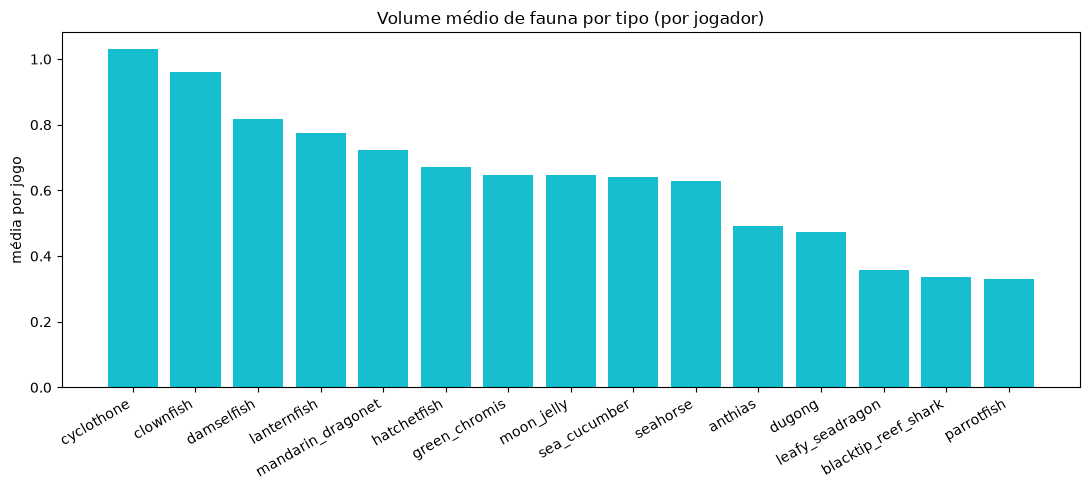

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
means = flong[fcols].mean().sort_values(ascending=False)
ax.bar([c[len('fauna_'):] for c in means.index], means.values, color='tab:cyan')
ax.set_title('Volume médio de fauna por tipo (por jogador)'); ax.set_ylabel('média por jogo')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## Pontos marginais por fauna (regressão)

`score ~ intercepto + Σ volumes de fauna`. Estima quantos pontos cada fauna adicional traz, em média.

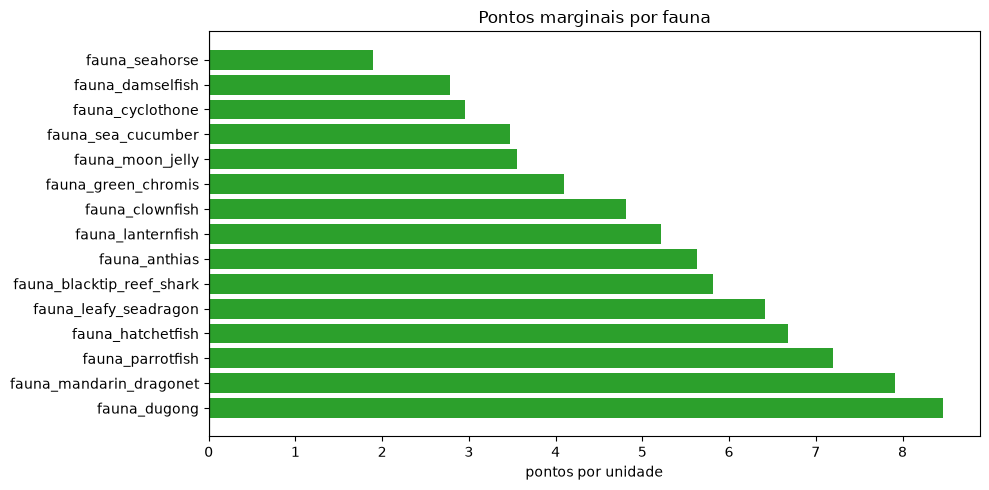

,pontos_por_fauna
fauna_dugong,8.47
fauna_mandarin_dragonet,7.91
fauna_parrotfish,7.20
fauna_hatchetfish,6.68
fauna_leafy_seadragon,6.41
(intercepto),6.31
fauna_blacktip_reef_shark,5.81
fauna_anthias,5.63
fauna_lanternfish,5.21
fauna_clownfish,4.81


In [7]:
X = np.column_stack([np.ones(len(flong))] + [flong[c].values.astype(float) for c in fcols])
y = flong['score'].values.astype(float)
coef, *_ = np.linalg.lstsq(X, y, rcond=None)
reg = pd.Series(coef, index=['(intercepto)'] + fcols).round(2).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
body = reg.drop('(intercepto)')
ax.barh(body.index, body.values, color=['tab:green' if v >= 0 else 'tab:red' for v in body.values])
ax.axvline(0, color='k', linewidth=0.8)
ax.set_title('Pontos marginais por fauna'); ax.set_xlabel('pontos por unidade')
plt.tight_layout(); plt.show()
reg.to_frame('pontos_por_fauna')

## Vitória × nº de cartas de cada fauna (do jogador)

Para cada tipo de fauna: a **% de vitória** do jogador conforme quantas cartas daquela fauna ele
tem naquele jogo. A linha pontilhada cinza é o winrate-base. Os números sob cada ponto são a
quantidade de observações (contagens raras são ruidosas).

> Correlacional: quem vence tende a jogar mais de tudo — leia como associação, não causa.

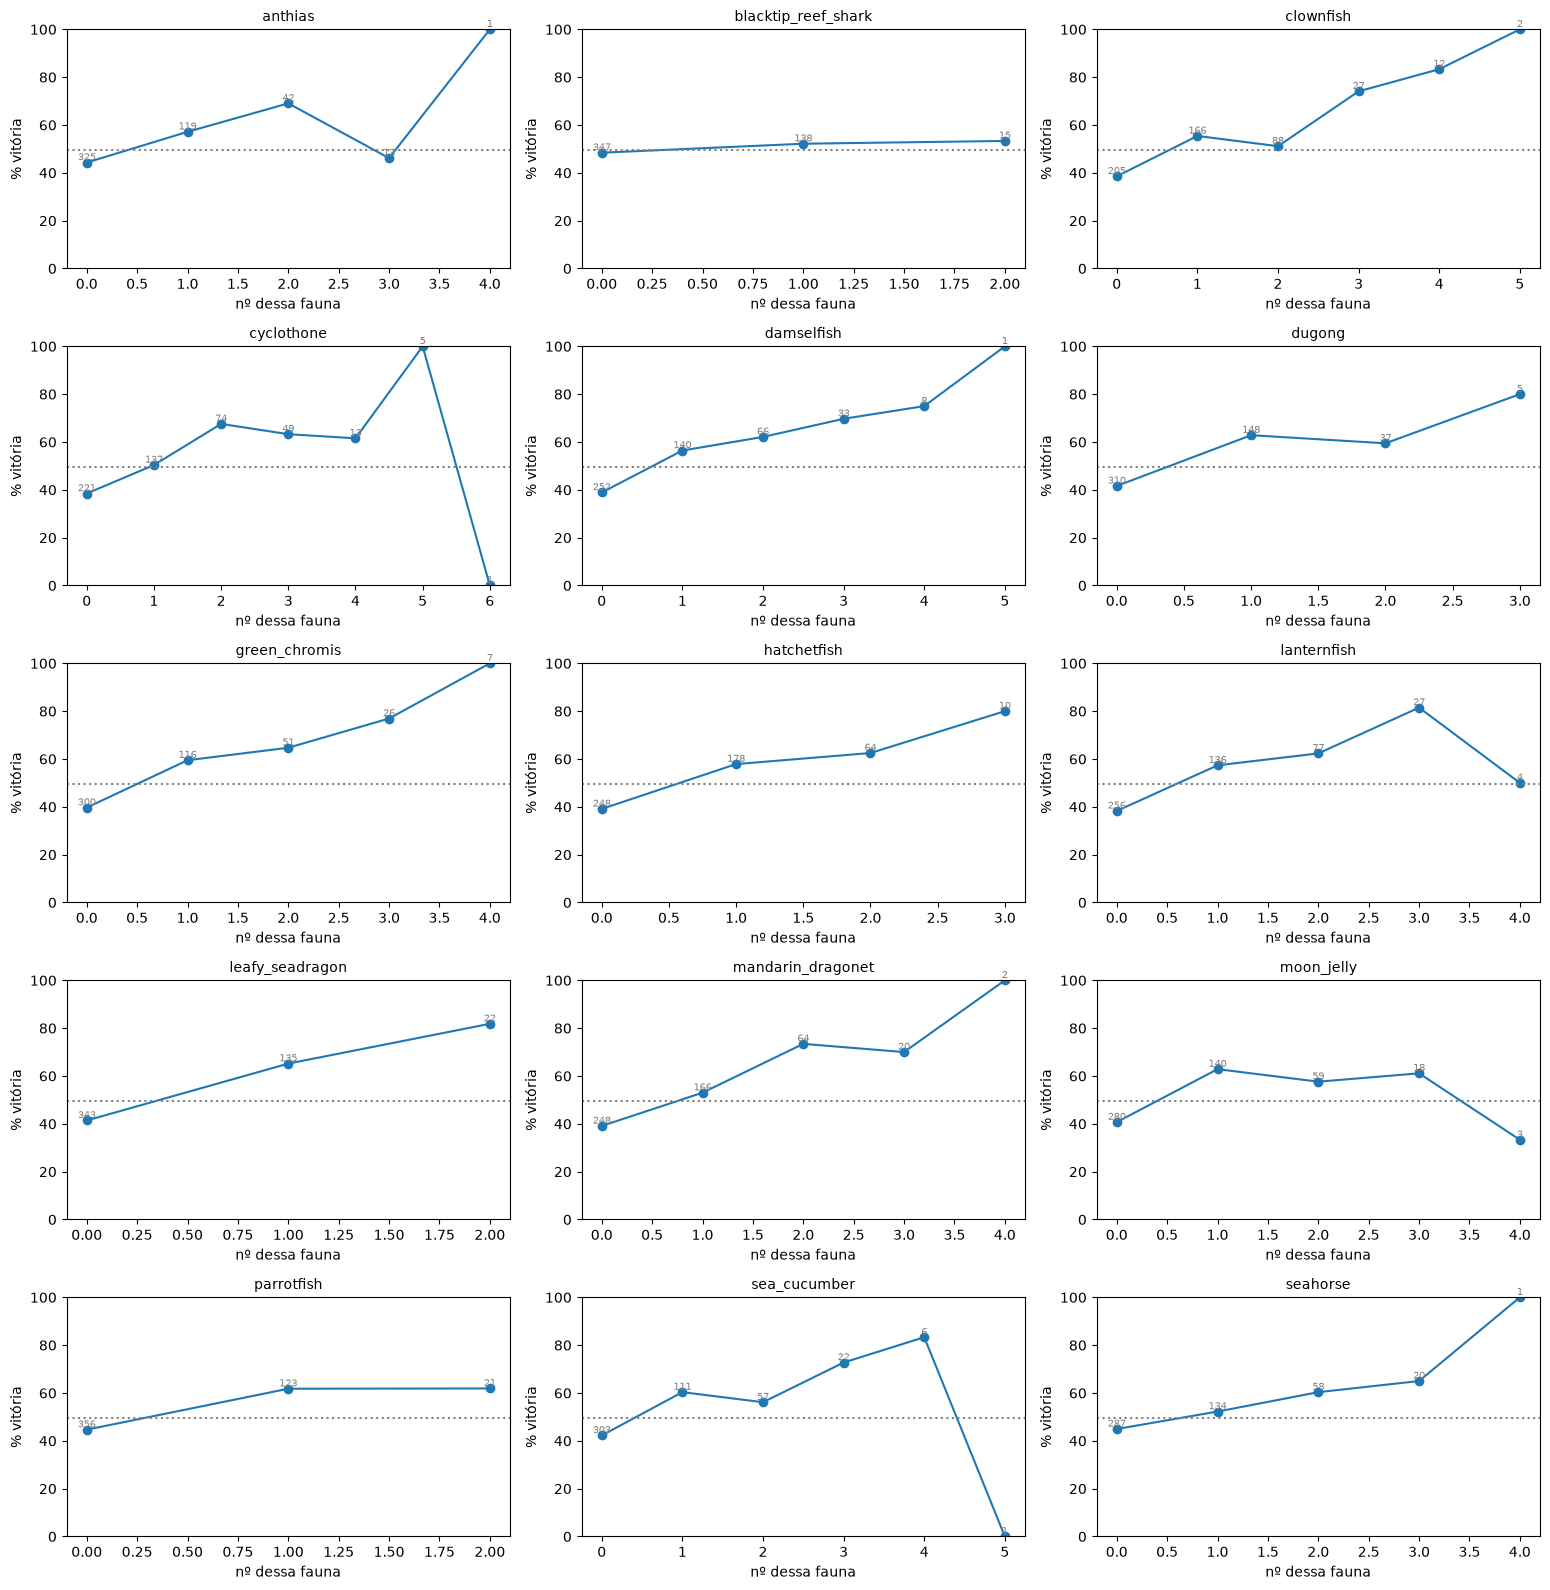

In [13]:
# Long por jogador com 'venceu' + contagem de cada fauna.
plong = pd.concat([
    pd.DataFrame(dict(
        {'won': (res['winner'] == pid).astype(int)},
        **{f'fauna_{ft}': res[f'p{pid}_fauna_{ft}'] for ft in fauna_types},
    ))
    for pid in (1, 2)
], ignore_index=True)

base_wr = plong['won'].mean() * 100
n = len(fauna_types)
ncol = 3
nrow = (n + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(5.2 * ncol, 3.2 * nrow), squeeze=False)
for idx, ft in enumerate(fauna_types):
    ax = axes[idx // ncol][idx % ncol]
    col = f'fauna_{ft}'
    grp = plong.groupby(col)['won'].agg(['mean', 'size'])
    ax.plot(grp.index, grp['mean'] * 100, marker='o', color='tab:blue')
    for x, (m, sz) in zip(grp.index, grp.values):
        ax.annotate(int(sz), (x, m * 100), fontsize=7, ha='center', va='bottom', color='gray')
    ax.axhline(base_wr, ls=':', color='gray')
    ax.set_title(ft, fontsize=10); ax.set_xlabel('nº dessa fauna'); ax.set_ylabel('% vitória')
    ax.set_ylim(0, 100)
for j in range(n, nrow * ncol):
    axes[j // ncol][j % ncol].axis('off')
plt.tight_layout(); plt.show()

## Resumo: winrate SEM vs COM a fauna (≥1)

Compacto: para cada fauna, o winrate do jogador quando **não** a tem vs quando tem **≥1**, e o delta.

In [9]:
rows = []
for ft in fauna_types:
    col = f'fauna_{ft}'
    has = plong[plong[col] >= 1]['won']
    hasnt = plong[plong[col] == 0]['won']
    rows.append({
        'fauna': ft,
        'winrate_sem_%': round(hasnt.mean() * 100, 1) if len(hasnt) else float('nan'),
        'winrate_com>=1_%': round(has.mean() * 100, 1) if len(has) else float('nan'),
        'delta_%': round((has.mean() - hasnt.mean()) * 100, 1) if len(has) and len(hasnt) else float('nan'),
        'jogos_com>=1': int((plong[col] >= 1).sum()),
    })
pd.DataFrame(rows).sort_values('delta_%', ascending=False).reset_index(drop=True)

,fauna,winrate_sem_%,winrate_com>=1_%,delta_%,jogos_com>=1
0,leafy_seadragon,41.4,67.5,26.1,157
1,green_chromis,39.7,64.5,24.8,200
2,lanternfish,38.3,61.5,23.2,244
3,damselfish,38.9,60.5,21.6,248
4,dugong,41.6,62.6,21.0,190
5,mandarin_dragonet,39.1,59.9,20.8,252
6,hatchetfish,39.1,59.9,20.8,252
7,moon_jelly,40.7,60.9,20.2,220
8,cyclothone,38.5,58.4,20.0,279
9,clownfish,38.5,57.3,18.8,295


In [14]:
rows = []
for ft in fauna_types:
    col = f'fauna_{ft}'
    grp = plong.groupby(col)['won'].agg(['mean', 'size']).reset_index()
    rows.append({
        'fauna': ft,
        'winrate_medio_%': round(grp['mean'].mean() * 100, 1),
        'winrate_mediano_%': round(grp['mean'].median() * 100, 1),
        'winrate_medio_ponderado_%': round(np.average(grp['mean'], weights=grp['size']) * 100, 1),
        'n_faixas_qtd': int(len(grp)),
        'observacoes': int(grp['size'].sum()),
    })

pd.DataFrame(rows).sort_values('winrate_medio_%', ascending=False).reset_index(drop=True)

,fauna,winrate_medio_%,winrate_mediano_%,winrate_medio_ponderado_%,n_faixas_qtd,observacoes
0,green_chromis,68.2,64.7,49.6,5,500
1,clownfish,67.1,64.7,49.6,6,500
2,mandarin_dragonet,67.1,70.0,49.6,5,500
3,damselfish,67.0,65.9,49.6,6,500
4,seahorse,64.5,60.3,49.6,5,500
5,anthias,63.3,57.1,49.6,5,500
6,leafy_seadragon,62.8,65.2,49.6,3,500
7,dugong,61.0,61.1,49.6,4,500
8,hatchetfish,59.9,60.2,49.6,4,500
9,lanternfish,57.9,57.4,49.6,5,500


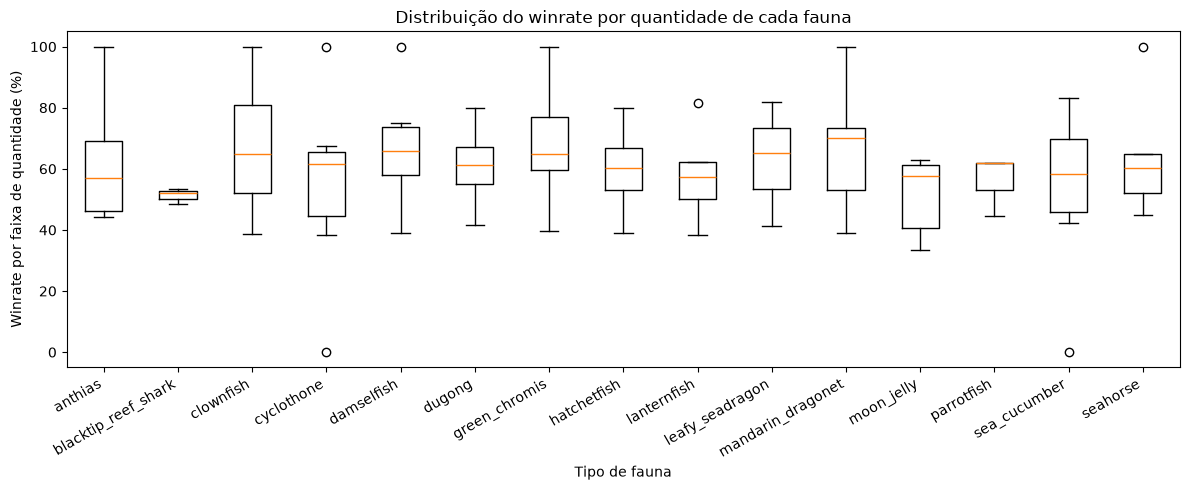

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
boxplot_data = [plong.groupby(f'fauna_{ft}')['won'].apply(lambda x: x.mean() * 100).values for ft in fauna_types]
ax.boxplot(boxplot_data)
ax.set_xticklabels(fauna_types)
ax.set_title('Distribuição do winrate por quantidade de cada fauna')
ax.set_ylabel('Winrate por faixa de quantidade (%)')
ax.set_xlabel('Tipo de fauna')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()